# Filter Benchmark + EfficientNetV2-L (Train from Scratch)


In [1]:
import os
import json
import copy
import random
import warnings
from typing import Callable

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import efficientnet_v2_l

from monai.losses import FocalLoss
from monai.utils import set_determinism

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

DATA_ROOT = '/mounts/mecd-ap-g5/data'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'filter_benchmark_efficientnet_v2_l_scratch_fixed'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
NUM_EPOCHS = 40          # scratch training needs more epochs
PATIENCE = 20            # wider patience window for cold-start convergence
LEARNING_RATE = 1e-4     # higher LR — no pretrained features to protect
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5        # linear warmup before cosine annealing
USE_PRETRAINED = True  # ← train from scratch
GEOMETRY_MODE = 'direct_resize'  # options: direct_resize, pad_resize_if_rect
USE_CLAHE = True

# Dataset-specific normalisation (computed below from training set).
# Falls back to ImageNet stats if computation is skipped.
IMAGENET_MEAN = [0.485, 0.456, 0.406]  # placeholder; overwritten in cell 5
IMAGENET_STD  = [0.229, 0.224, 0.225]  # placeholder; overwritten in cell 5

set_determinism(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', torch.cuda.get_device_properties(0).total_memory / 1e9)
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:', MODELS_DIR)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM (GB): 50.86216192
RESULTS_DIR: /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_l_scratch_fixed
MODELS_DIR: /mounts/mecd-ap-g5/models/filter_benchmark_efficientnet_v2_l_scratch_fixed


In [2]:
METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
df = pd.read_csv(METADATA_PATH)

EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
FUSED_LABEL_MAP = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}
FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']

filtered = df[(df['Keep'].astype(str).str.strip().str.lower() == 'keep') & (~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))].copy()
filtered['Label'] = filtered['Label'].astype(str).str.strip()
filtered['final_label'] = filtered['Label'].map(FUSED_LABEL_MAP)
filtered = filtered[filtered['final_label'].isin(FINAL_CLASSES)].copy()
filtered['image_path'] = filtered['processed_image_path'].apply(lambda p: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', p))
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

class_names = list(FINAL_CLASSES)
class_to_idx = {label_name: idx for idx, label_name in enumerate(class_names)}
filtered['target'] = filtered['final_label'].map(class_to_idx)

print('Total filtered samples:', len(filtered))
print('Class distribution:')
print(filtered['final_label'].value_counts())
print('Image type distribution:')
print(filtered['image_type'].value_counts())

Total filtered samples: 1568
Class distribution:
final_label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64
Image type distribution:
image_type
S    1521
V      47
Name: count, dtype: int64


In [3]:
patient_summary = filtered.groupby('patient_id').agg(patient_label=('final_label', lambda x: x.mode().iloc[0])).reset_index()
train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label']
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label']
)

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy().reset_index(drop=True)
val_df = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy().reset_index(drop=True)
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy().reset_index(drop=True)

print('Split sizes:')
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{split_name} label distribution:')
    print(split_df['final_label'].value_counts())
    print(f'{split_name} image_type distribution:')
    print(split_df['image_type'].value_counts())

Split sizes:
train: 1001 val: 313 test: 254

train label distribution:
final_label
Lithiasis        468
Stricture        249
Normal           206
Biliary Leaks     78
Name: count, dtype: int64
train image_type distribution:
image_type
S    967
V     34
Name: count, dtype: int64

val label distribution:
final_label
Lithiasis        142
Stricture         58
Normal            58
Biliary Leaks     55
Name: count, dtype: int64
val image_type distribution:
image_type
S    304
V      9
Name: count, dtype: int64

test label distribution:
final_label
Lithiasis        116
Stricture         85
Normal            35
Biliary Leaks     18
Name: count, dtype: int64
test image_type distribution:
image_type
S    250
V      4
Name: count, dtype: int64


In [4]:
# ── Data leakage verification ──────────────────────────────────────────────
# Proves no patient appears in more than one split.
train_patients_set = set(train_df["patient_id"].astype(str))
val_patients_set   = set(val_df["patient_id"].astype(str))
test_patients_set  = set(test_df["patient_id"].astype(str))

print("Interseção treino-val  :", len(train_patients_set & val_patients_set))
print("Interseção treino-teste:", len(train_patients_set & test_patients_set))
print("Interseção val-teste   :", len(val_patients_set   & test_patients_set))

assert len(train_patients_set & val_patients_set)   == 0, "LEAKAGE: patients shared between train and val!"
assert len(train_patients_set & test_patients_set)  == 0, "LEAKAGE: patients shared between train and test!"
assert len(val_patients_set   & test_patients_set)  == 0, "LEAKAGE: patients shared between val and test!"
print("\n✓ No patient leakage detected across splits.")


Interseção treino-val  : 0
Interseção treino-teste: 0
Interseção val-teste   : 0

✓ No patient leakage detected across splits.


In [5]:
def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas

def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)

def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=False) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    elif geometry_mode == 'direct_resize':
        pass
    else:
        raise ValueError(f'Unknown geometry_mode: {geometry_mode}')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    return image

In [6]:
# ── Compute dataset-specific mean & std from training images ──────────────
# Runs before ERCPDataset is defined — uses PIL + numpy directly.
import numpy as np
from PIL import Image

print('Computing dataset mean & std from training images …')
_pixel_sum   = np.zeros(3, dtype=np.float64)
_pixel_sq_sum = np.zeros(3, dtype=np.float64)
_pixel_count  = 0

for _path in train_df['image_path']:
    try:
        _img = Image.open(_path).convert('RGB')
        # apply same preprocessing as training (CLAHE + geometry)
        _img = preprocess_image(_img, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
        _arr = np.array(_img, dtype=np.float64) / 255.0  # H×W×3, [0,1]
        _pixel_sum    += _arr.sum(axis=(0, 1))
        _pixel_sq_sum += (_arr ** 2).sum(axis=(0, 1))
        _pixel_count  += _arr.shape[0] * _arr.shape[1]
    except Exception:
        pass

_mean = _pixel_sum / _pixel_count
_std  = np.sqrt(_pixel_sq_sum / _pixel_count - _mean ** 2)

IMAGENET_MEAN = _mean.tolist()
IMAGENET_STD  = np.clip(_std, 1e-7, None).tolist()  # avoid zero std
print(f'Dataset mean: {[f"{v:.4f}" for v in IMAGENET_MEAN]}')
print(f'Dataset std:  {[f"{v:.4f}" for v in IMAGENET_STD]}')


Computing dataset mean & std from training images …
Dataset mean: ['0.3594', '0.3594', '0.3593']
Dataset std:  ['0.2564', '0.2564', '0.2564']


In [7]:
class ERCPDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Callable, geometry_mode='pad_resize_if_rect', use_clahe=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.geometry_mode = geometry_mode
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        image = self.transform(image)
        target = int(row['target'])
        return image, target

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ERCPDataset(train_df, train_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
val_ds = ERCPDataset(val_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds = ERCPDataset(test_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=device)
weight_lookup = {i: float(w) for i, w in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Class weights:', class_weights)

Class weights: tensor([3.2083, 0.5347, 1.2148, 1.0050], device='cuda:0')


In [8]:
import math

def build_efficientnet_v2_l(num_classes, pretrained=False):
    try:
        from torchvision.models import EfficientNet_V2_L_Weights
        weights = EfficientNet_V2_L_Weights.DEFAULT if pretrained else None
        model = efficientnet_v2_l(weights=weights)
    except Exception:
        model = efficientnet_v2_l(pretrained=pretrained)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    if not pretrained:
        # Kaiming He initialisation for all conv and linear layers
        for m in model.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)
    return model


def make_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warmup then cosine annealing — better for scratch training."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))
        progress = (epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics

In [9]:
def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs


def train_model():
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = FocalLoss(to_onehot_y=True)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_macro_f1': train_f1,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc': val_metrics['roc_auc_ovo_macro'],
        })

        scheduler.step()

        print(f"Epoch {epoch + 1:02d} | train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | val_f1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth'))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_geometry.csv'), index=False)
    return model, history_df, best_epoch, best_val_f1

In [36]:
# ── Train the model ─────────────────────────────────────────────────────────
# Runs full training from scratch. Skip this cell (and load from checkpoint
# below) if you have already trained and just want to re-run evaluation.
model, history_df, best_epoch, best_val_f1 = train_model()
print(f"Training complete. Best epoch: {best_epoch}, best val macro F1: {best_val_f1:.4f}")


Epoch 01 | train_loss 0.1263 | train_f1 0.5131 | val_f1 0.4702
Epoch 02 | train_loss 0.0886 | train_f1 0.7076 | val_f1 0.5025
Epoch 03 | train_loss 0.0682 | train_f1 0.7835 | val_f1 0.4384
Epoch 04 | train_loss 0.0504 | train_f1 0.8645 | val_f1 0.4304
Epoch 05 | train_loss 0.0431 | train_f1 0.9028 | val_f1 0.4308
Epoch 06 | train_loss 0.0385 | train_f1 0.8912 | val_f1 0.4031
Epoch 07 | train_loss 0.0317 | train_f1 0.9164 | val_f1 0.4084
Epoch 08 | train_loss 0.0226 | train_f1 0.9448 | val_f1 0.4666
Epoch 09 | train_loss 0.0200 | train_f1 0.9492 | val_f1 0.4161
Epoch 10 | train_loss 0.0184 | train_f1 0.9627 | val_f1 0.4692
Epoch 11 | train_loss 0.0137 | train_f1 0.9714 | val_f1 0.4294
Epoch 12 | train_loss 0.0297 | train_f1 0.9401 | val_f1 0.4780
Epoch 13 | train_loss 0.0116 | train_f1 0.9750 | val_f1 0.4629
Epoch 14 | train_loss 0.0085 | train_f1 0.9817 | val_f1 0.4207
Epoch 15 | train_loss 0.0140 | train_f1 0.9668 | val_f1 0.5276
Epoch 16 | train_loss 0.0116 | train_f1 0.9704 | val_f1

Best epoch: 15
Best val macro F1: 0.5275837822634732


,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy,val_auc
30,31,0.000462,1.000000,0.397580,0.473064,0.597444,0.810501
31,32,0.000264,1.000000,0.430779,0.434664,0.568690,0.795366
32,33,0.000505,1.000000,0.397869,0.447581,0.575080,0.801498
33,34,0.000524,0.999036,0.405802,0.438900,0.571885,0.799920
34,35,0.000344,1.000000,0.384448,0.467710,0.597444,0.807958


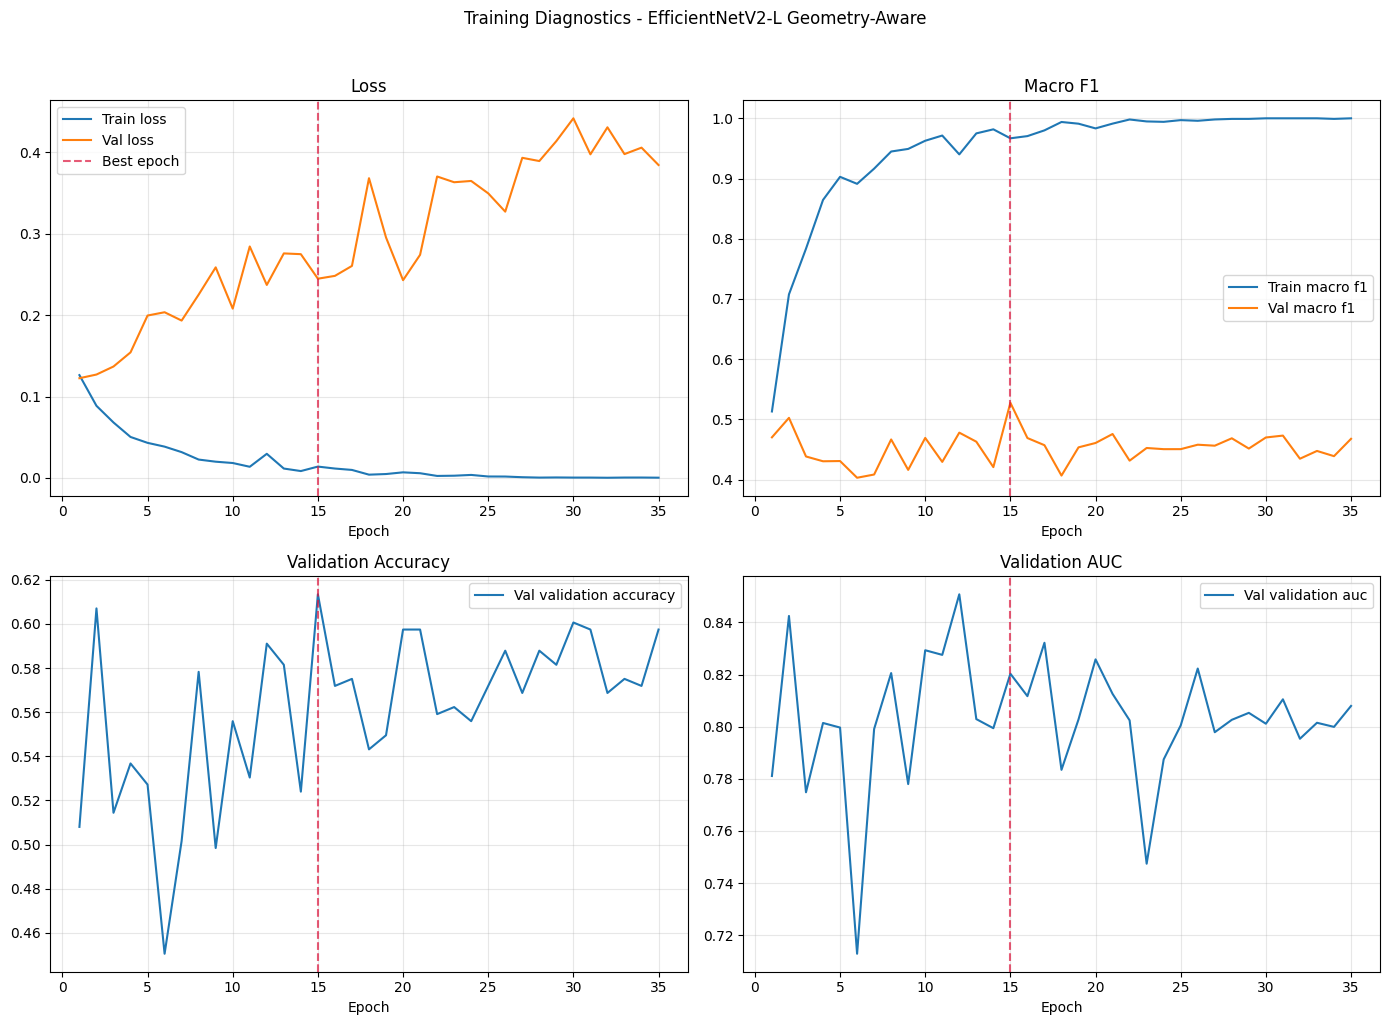

In [37]:
history_path = os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_geometry.csv')
checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth')

history_df = globals().get('history_df')
if history_df is None or history_df.empty:
    if os.path.exists(history_path):
        history_df = pd.read_csv(history_path)
    else:
        raise FileNotFoundError(f'Missing training history at {history_path}. Use the already-trained notebook kernel or rerun a saved training job.')

history_df = history_df.sort_values('epoch').reset_index(drop=True)
history_df.to_csv(history_path, index=False)

best_epoch = globals().get('best_epoch')
if best_epoch is None:
    best_epoch = int(history_df.loc[history_df['val_macro_f1'].idxmax(), 'epoch'])
best_val_f1 = globals().get('best_val_f1')
if best_val_f1 is None:
    best_val_f1 = float(history_df['val_macro_f1'].max())

model = globals().get('model')
if model is None:
    model = build_efficientnet_v2_l(len(class_names), pretrained=False).to(device)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

print('Best epoch:', best_epoch)
print('Best val macro F1:', best_val_f1)
display(history_df.tail())

plot_cols = [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_macro_f1', 'val_macro_f1', 'Macro F1'),
    (None, 'val_accuracy', 'Validation Accuracy'),
    (None, 'val_auc', 'Validation AUC'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, (train_col, val_col, title) in zip(axes, plot_cols):
    if train_col is not None and train_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[train_col], label=f'Train {title.lower()}')
    if val_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[val_col], label=f'Val {title.lower()}')
    ax.axvline(best_epoch, color='crimson', linestyle='--', alpha=0.7, label='Best epoch' if ax is axes[0] else None)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Training Diagnostics - EfficientNetV2-L Geometry-Aware', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics_efficientnet_v2_l_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

summary_rows = [{
    'best_epoch': best_epoch,
    'best_val_macro_f1': best_val_f1,
    'final_val_loss': float(history_df['val_loss'].iloc[-1]) if 'val_loss' in history_df.columns else np.nan,
    'final_val_accuracy': float(history_df['val_accuracy'].iloc[-1]) if 'val_accuracy' in history_df.columns else np.nan,
    'final_val_auc': float(history_df['val_auc'].iloc[-1]) if 'val_auc' in history_df.columns else np.nan,
}]
pd.DataFrame(summary_rows).to_csv(os.path.join(RESULTS_DIR, 'training_summary_efficientnet_v2_l_geometry.csv'), index=False)

TEST METRICS (global)
  accuracy                      : 0.7441
  balanced_accuracy             : 0.6453
  macro_f1                      : 0.6344
  macro_precision               : 0.6513
  macro_recall                  : 0.6453
  roc_auc_ovo_macro             : 0.8841
  pr_auc_macro                  : 0.6809
  loss                          : 0.1387

PER-CLASS METRICS
               precision    recall  f1-score   support

Biliary Leaks     0.4000    0.2222    0.2857        18
    Lithiasis     0.7823    0.8362    0.8083       116
       Normal     0.5800    0.8286    0.6824        35
    Stricture     0.8429    0.6941    0.7613        85

     accuracy                         0.7441       254
    macro avg     0.6513    0.6453    0.6344       254
 weighted avg     0.7476    0.7441    0.7382       254


Per-class summary table:


,Precision,Recall,F1-score,Support
Biliary Leaks,0.4000,0.2222,0.2857,18
Lithiasis,0.7823,0.8362,0.8083,116
Normal,0.5800,0.8286,0.6824,35
Stricture,0.8429,0.6941,0.7613,85



Averages:


,Precision,Recall,F1-score
macro avg,0.6513,0.6453,0.6344
weighted avg,0.7476,0.7441,0.7382


,model,geometry_mode,use_clahe,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_roc_auc_ovo_macro,test_pr_auc_macro,...,test_Normal_f1,test_Stricture_f1,test_Biliary Leaks_precision,test_Lithiasis_precision,test_Normal_precision,test_Stricture_precision,test_Biliary Leaks_recall,test_Lithiasis_recall,test_Normal_recall,test_Stricture_recall
0,efficientnet_v2_l_scratch,direct_resize,True,0.744094,0.64528,0.634423,0.651279,0.64528,0.884087,0.680853,...,0.682353,0.76129,0.4,0.782258,0.58,0.842857,0.222222,0.836207,0.828571,0.694118


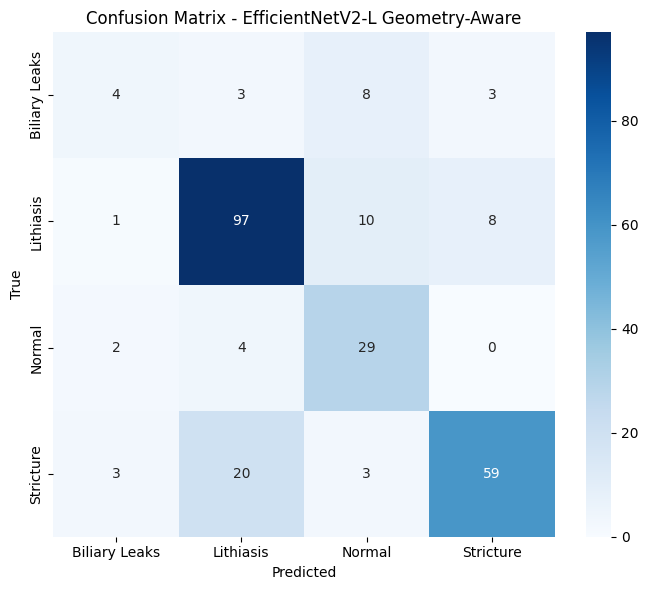

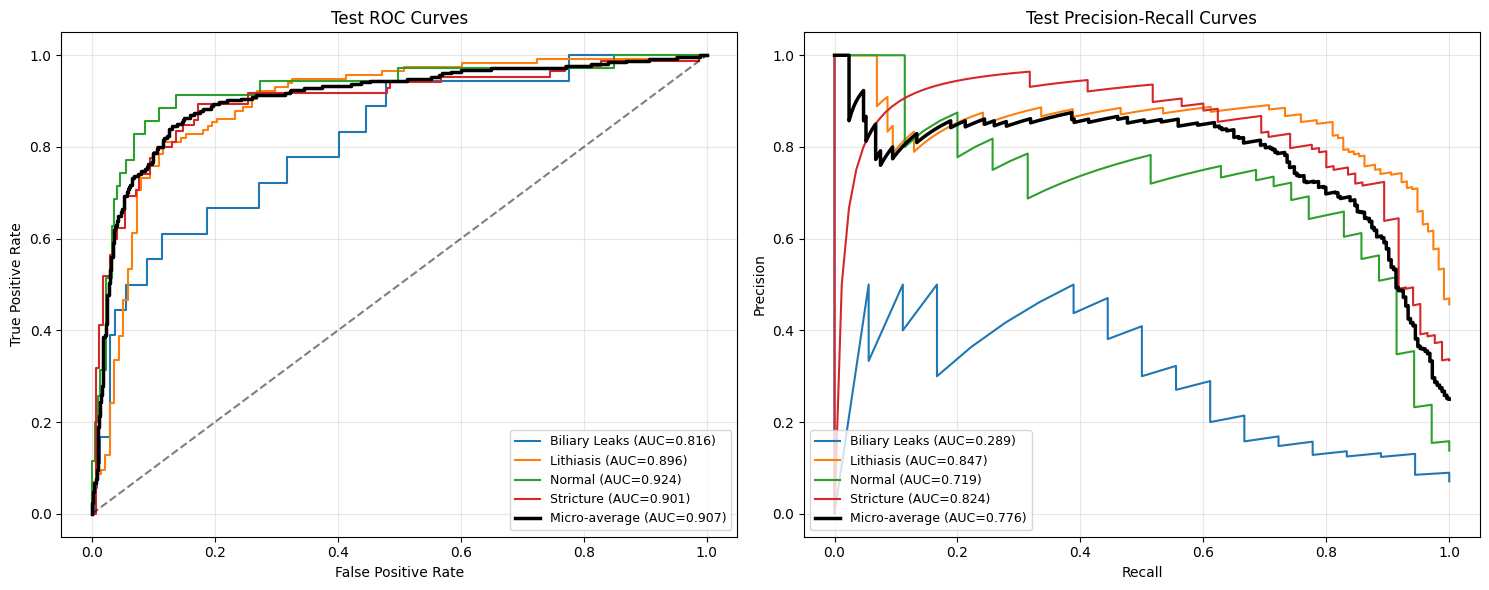

In [38]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth')
model = globals().get('model')
if model is None:
    model = build_efficientnet_v2_l(len(class_names), pretrained=False).to(device)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

criterion = FocalLoss(to_onehot_y=True)
test_metrics = globals().get('test_metrics')
y_true = globals().get('y_true')
y_pred = globals().get('y_pred')
y_prob = globals().get('y_prob')
if test_metrics is None or y_true is None or y_prob is None:
    test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

# ── Global (macro) metrics ───────────────────────────────────────────────
print('=' * 60)
print('TEST METRICS (global)')
print('=' * 60)
for k, v in test_metrics.items():
    print(f'  {k:<30s}: {v:.4f}' if isinstance(v, (float, np.floating)) else f'  {k}: {v}')

# ── Per-class detailed report ────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print('\n' + '=' * 60)
print('PER-CLASS METRICS')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

# Styled per-class DataFrame
report_df = pd.DataFrame(report).transpose()
per_class_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score', 'support']].copy()
per_class_df.columns = ['Precision', 'Recall', 'F1-score', 'Support']
per_class_df['Support'] = per_class_df['Support'].astype(int)
print('\nPer-class summary table:')
display(per_class_df.style
    .format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-score': '{:.4f}'})
    .background_gradient(subset=['F1-score'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption('Per-class Precision / Recall / F1 (test set)'))

avg_rows = ['macro avg', 'weighted avg']
avg_df = report_df.loc[[r for r in avg_rows if r in report_df.index],
                        ['precision', 'recall', 'f1-score']].copy()
avg_df.columns = ['Precision', 'Recall', 'F1-score']
print('\nAverages:')
display(avg_df.style.format('{:.4f}').set_caption('Macro & Weighted averages'))

# Save reports
with open(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_l_geometry.json'), 'w') as f:
    json.dump(report, f, indent=2)
report_df.to_csv(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_l_geometry.csv'))
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_l_geometry.csv'))

summary = pd.DataFrame([{
    'model': 'efficientnet_v2_l_scratch',
    'geometry_mode': GEOMETRY_MODE,
    'use_clahe': USE_CLAHE,
    **{f'test_{k}': v for k, v in test_metrics.items()},
    **{f'test_{cls}_f1': report[cls]['f1-score'] for cls in class_names},
    **{f'test_{cls}_precision': report[cls]['precision'] for cls in class_names},
    **{f'test_{cls}_recall': report[cls]['recall'] for cls in class_names},
}])
summary.to_csv(os.path.join(RESULTS_DIR, 'test_summary_efficientnet_v2_l_geometry.csv'), index=False)
display(summary)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetV2-L Geometry-Aware')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_l_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_prob[:, idx])
    roc_auc_value = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc_value:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].plot(fpr_micro, tpr_micro, label=f'Micro-average (AUC={roc_auc_micro:.3f})', linewidth=2.5, color='black')
axes[0].set_title('Test ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)
for idx, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_prob[:, idx])
    pr_auc_value = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{class_name} (AUC={pr_auc_value:.3f})')
axes[1].plot(recall_micro, precision_micro, label=f'Micro-average (AUC={pr_auc_micro:.3f})', linewidth=2.5, color='black')
axes[1].set_title('Test Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_pr_curves_efficientnet_v2_l_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

In [39]:
# ── Baseline comparison (macro F1) ─────────────────────────────────────────
BASELINE_MACRO_F1 = 0.738   # previous best result

our_macro_f1 = test_metrics.get('macro_f1', float('nan'))
delta        = our_macro_f1 - BASELINE_MACRO_F1
pct_change   = delta / BASELINE_MACRO_F1 * 100

print("=" * 55)
print("BASELINE vs THIS MODEL")
print("=" * 55)
print(f"  Baseline macro F1   : {BASELINE_MACRO_F1:.4f}")
print(f"  This model macro F1 : {our_macro_f1:.4f}")
print(f"  Δ (absolute)        : {delta:+.4f}")
print(f"  Δ (relative)        : {pct_change:+.2f}%")
print()
if delta > 0:
    print(f"  ✓ IMPROVEMENT of {delta:+.4f} over baseline")
elif delta == 0:
    print("  = Tied with baseline")
else:
    print(f"  ✗ Below baseline by {abs(delta):.4f}")
print("=" * 55)

# Save to results
comparison_df = pd.DataFrame([{
    'model':             'efficientnet_v2_l_scratch',
    'baseline_macro_f1': BASELINE_MACRO_F1,
    'model_macro_f1':    our_macro_f1,
    'delta':             delta,
    'pct_change':        pct_change,
}])
comparison_df.to_csv(os.path.join(RESULTS_DIR, 'baseline_comparison.csv'), index=False)
display(comparison_df)


BASELINE vs THIS MODEL
  Baseline macro F1   : 0.7380
  This model macro F1 : 0.6344
  Δ (absolute)        : -0.1036
  Δ (relative)        : -14.03%

  ✗ Below baseline by 0.1036


,model,baseline_macro_f1,model_macro_f1,delta,pct_change
0,efficientnet_v2_l_scratch,0.738,0.634423,-0.103577,-14.034862


In [40]:
# ── Per-sample probability table ────────────────────────────────────────────
# Ensure y_true, y_pred, y_prob are available (run evaluation cell if not).
y_true_local = globals().get('y_true')
y_pred_local = globals().get('y_pred')
y_prob_local = globals().get('y_prob')
if y_true_local is None:
    criterion = FocalLoss(to_onehot_y=True)
    test_metrics, y_true_local, y_pred_local, y_prob_local = evaluate(model, test_loader, criterion)

probs_df = pd.DataFrame(y_prob_local, columns=[f"prob_{c}" for c in class_names])
probs_df["true_label"] = [class_names[i] for i in y_true_local]
probs_df["pred_label"] = [class_names[i] for i in y_pred_local]
probs_df["correct"]    = probs_df["true_label"] == probs_df["pred_label"]

print(f"Test samples: {len(probs_df)}")
print(f"Correct predictions: {probs_df['correct'].sum()} / {len(probs_df)}")
print()
display(probs_df.head(10))

probs_df.to_csv(os.path.join(RESULTS_DIR, 'test_probabilities.csv'), index=False)
print(f"\nSaved to {os.path.join(RESULTS_DIR, 'test_probabilities.csv')}")


Test samples: 254
Correct predictions: 189 / 254



,prob_Biliary Leaks,prob_Lithiasis,prob_Normal,prob_Stricture,true_label,pred_label,correct
0,0.015995,0.005146,0.964183,0.014675,Normal,Normal,True
1,0.003125,0.000915,0.995099,0.000861,Normal,Normal,True
2,0.428622,0.126915,0.431123,0.013341,Lithiasis,Normal,False
3,0.016851,0.947385,0.032835,0.002928,Lithiasis,Lithiasis,True
4,0.034535,0.847127,0.114758,0.003580,Lithiasis,Lithiasis,True
5,0.024564,0.950492,0.014429,0.010515,Lithiasis,Lithiasis,True
6,0.014472,0.947736,0.015871,0.021922,Lithiasis,Lithiasis,True
7,0.779467,0.181584,0.034060,0.004889,Lithiasis,Biliary Leaks,False
8,0.007530,0.852603,0.054273,0.085594,Lithiasis,Lithiasis,True
9,0.001376,0.996119,0.000621,0.001884,Lithiasis,Lithiasis,True



Saved to /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_l_scratch_fixed/test_probabilities.csv


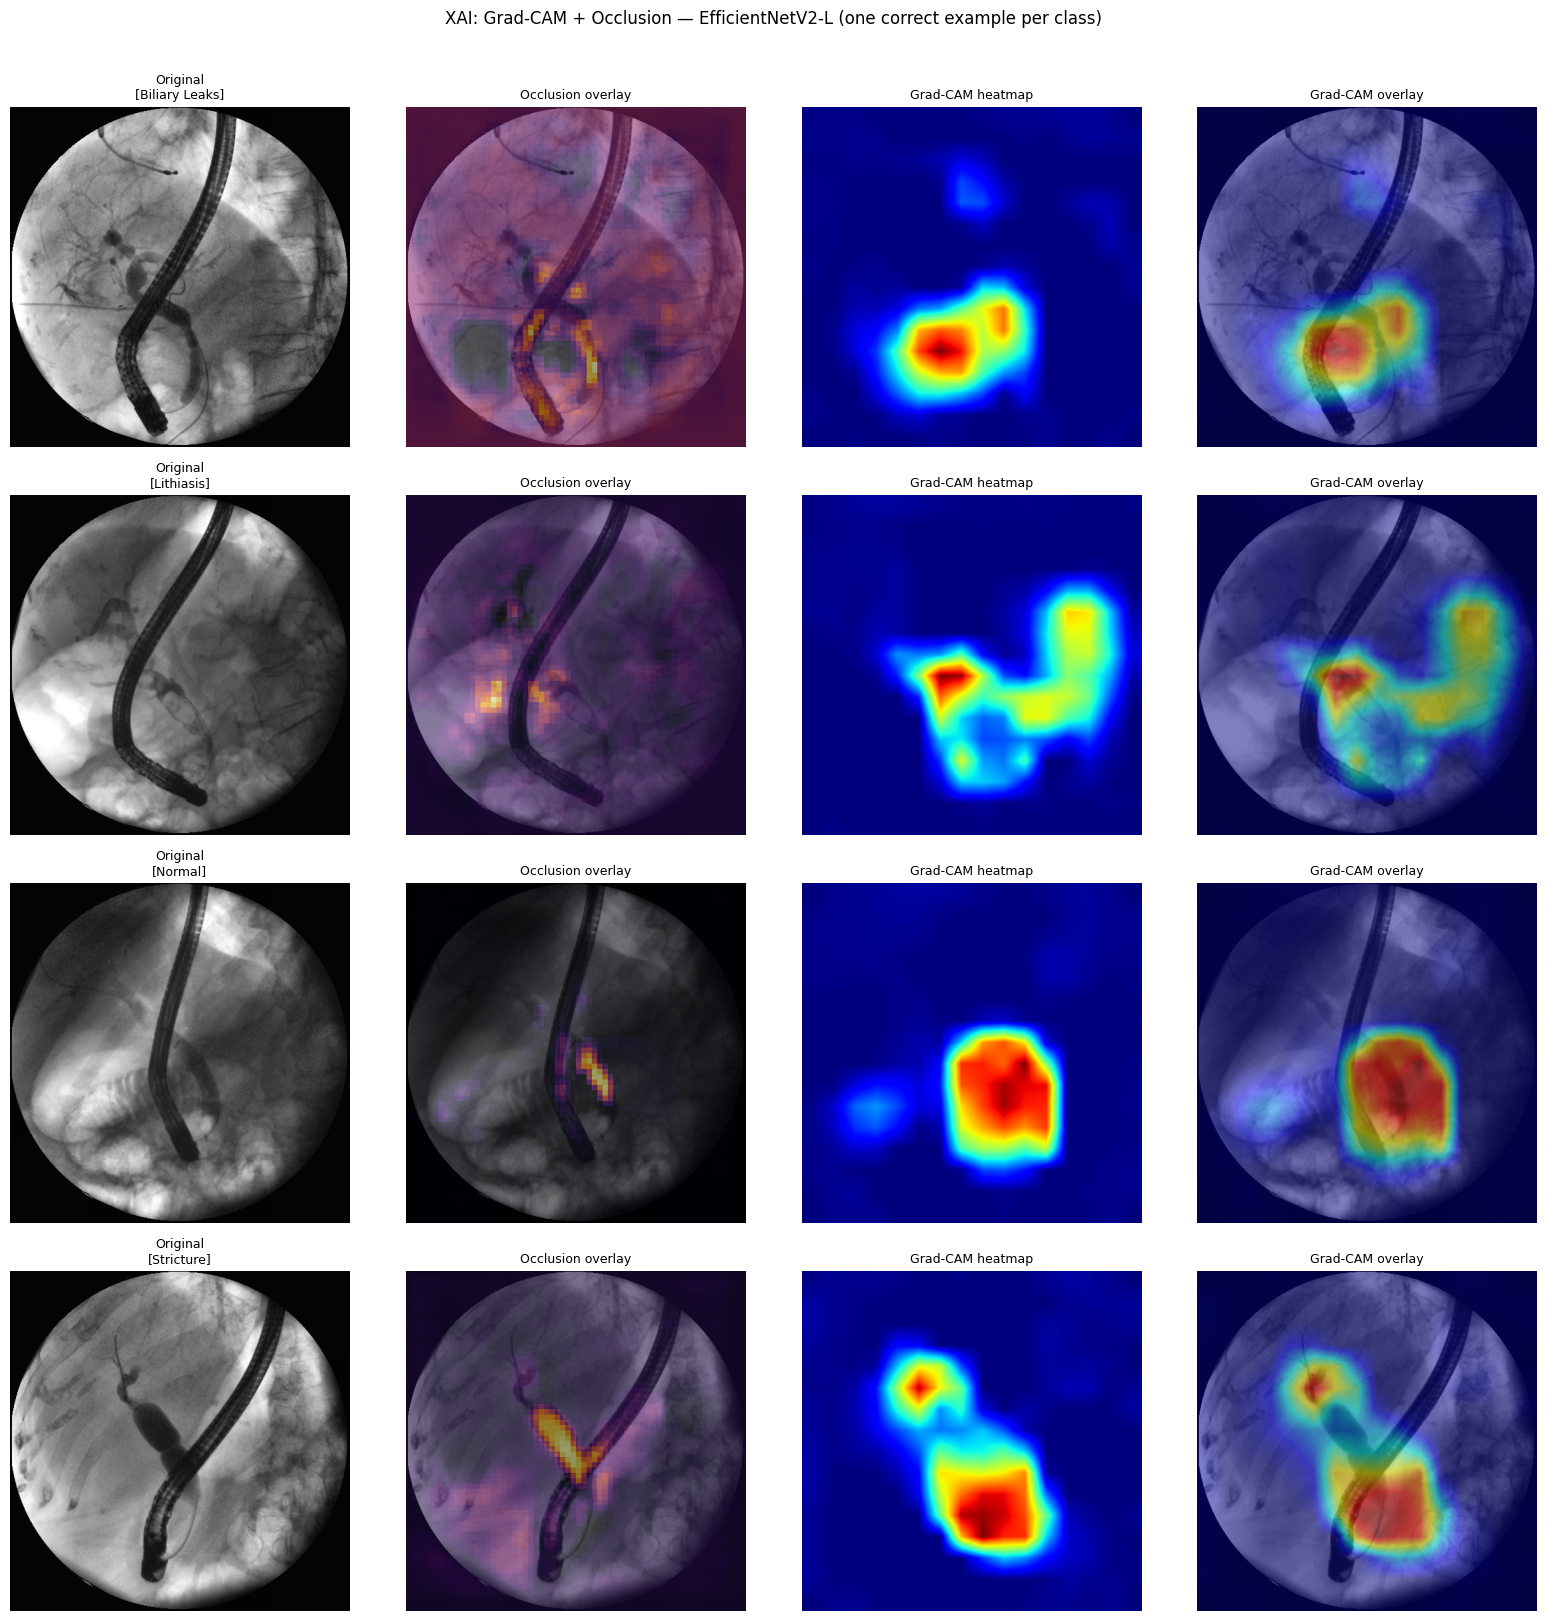


Saved to /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_l_scratch_fixed/xai_gradcam_occlusion.png


In [45]:
# ── Grad-CAM + Occlusion Sensitivity (one correct example per class) ────────
# Adapted to EfficientNetV2-L — target layer is the last conv block.

def _get_efficientnet_target_layer(model):
    """Return the last convolutional block of EfficientNetV2-L."""
    return model.features[-1]


class GradCAM:
    """Gradient-weighted Class Activation Mapping for any model with hooks."""

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._handles = []
        self._handles.append(target_layer.register_forward_hook(self._save_activation))
        self._handles.append(target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, _, __, output):
        self.activations = output.detach()

    def _save_gradient(self, _, _input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        for handle in self._handles:
            handle.remove()

    def __call__(self, input_tensor, target_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        logits[:, target_idx].sum().backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam


def occlusion_sensitivity(model, img_tensor, target_idx, patch=24, stride=12):
    """Patch-based occlusion map — returns normalised heatmap (H×W)."""
    model.eval()
    dev = next(model.parameters()).device
    img_tensor = img_tensor.to(dev)
    with torch.no_grad():
        base_prob = torch.softmax(model(img_tensor), dim=1)[0, target_idx].item()
    _, _, h, w = img_tensor.shape
    heat = np.zeros((h, w), dtype=np.float32)
    counts = np.zeros((h, w), dtype=np.float32)
    for y in range(0, h - patch + 1, stride):
        for x in range(0, w - patch + 1, stride):
            occ = img_tensor.clone()
            occ[:, :, y : y + patch, x : x + patch] = 0.0
            with torch.no_grad():
                prob = torch.softmax(model(occ), dim=1)[0, target_idx].item()
            drop = base_prob - prob
            heat[y : y + patch, x : x + patch] += drop
            counts[y : y + patch, x : x + patch] += 1.0
    heat = heat / np.maximum(counts, 1.0)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    return heat


def overlay_cam(image_pil, cam, alpha=0.5):
    img = np.array(image_pil.convert('RGB'))
    heat = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return (alpha * heat + (1 - alpha) * img).astype(np.uint8)


def show_xai_grid(patch=24, stride=12):
    """4-column grid: original | occlusion overlay | Grad-CAM heatmap | Grad-CAM overlay."""
    _model = globals().get('model')
    if _model is None:
        print("Model not available — run the training/loading cell first.")
        return

    _y_true = globals().get('y_true')
    _y_pred = globals().get('y_pred')
    if _y_true is None or _y_pred is None:
        print("Run evaluation cell first to get y_true / y_pred.")
        return

    dev = next(_model.parameters()).device
    _model.eval()

    target_layer = _get_efficientnet_target_layer(_model)
    gradcam = GradCAM(_model, target_layer)

    picks = []
    for cls_idx, cls_name in enumerate(class_names):
        correct_idxs = np.where((_y_true == cls_idx) & (_y_pred == cls_idx))[0]
        if len(correct_idxs):
            picks.append((int(correct_idxs[0]), cls_name))
        else:
            print(f"  No correct prediction for class '{cls_name}' — skipping.")

    if not picks:
        print("No correct predictions found; cannot visualise.")
        return

    fig, axes = plt.subplots(len(picks), 4, figsize=(16, 4 * len(picks)))
    if len(picks) == 1:
        axes = axes[np.newaxis, :]

    for row_i, (idx, cls_name) in enumerate(picks):
        row = test_df.iloc[idx]
        img_pil = Image.open(row['image_path']).convert('RGB')
        proc = preprocess_image(img_pil, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

        img_t = eval_transform(proc).unsqueeze(0).to(dev)
        pred_idx = int(_y_pred[idx])

        cam = gradcam(img_t, pred_idx)
        cam_overlay = overlay_cam(proc, cam)

        occl = occlusion_sensitivity(_model, img_t, pred_idx, patch=patch, stride=stride)

        axes[row_i, 0].imshow(proc)
        axes[row_i, 0].set_title(f"Original\n[{cls_name}]", fontsize=9)
        axes[row_i, 0].axis('off')

        ax1 = axes[row_i, 1]
        ax1.imshow(proc)
        ax1.imshow(occl, cmap='inferno', alpha=0.55)
        ax1.set_title('Occlusion overlay', fontsize=9)
        ax1.axis('off')

        axes[row_i, 2].imshow(cam, cmap='jet')
        axes[row_i, 2].set_title('Grad-CAM heatmap', fontsize=9)
        axes[row_i, 2].axis('off')

        axes[row_i, 3].imshow(cam_overlay)
        axes[row_i, 3].set_title('Grad-CAM overlay', fontsize=9)
        axes[row_i, 3].axis('off')

    plt.suptitle('XAI: Grad-CAM + Occlusion — EfficientNetV2-L (one correct example per class)', fontsize=12, y=1.01)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, 'xai_gradcam_occlusion.png')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"\nSaved to {save_path}")
    gradcam.remove_hooks()


# ── Run ─────────────────────────────────────────────────────────────────────
# patch=24, stride=12 is fast; use patch=16, stride=8 for finer maps (slower)
show_xai_grid(patch=16, stride=8)